In [1]:
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process.kernels import Matern

In [2]:
#Function 1
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 1.csv') 
columns = ['Input 1', 'Input 2', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.329743, 0.09222, 2.523075868634692e-133])
data.loc[len(data)] = new_data7
#Add Week 8's data to our pandas dataframe
new_data8 = np.array([0.251298, 0.141955, 6.248978856879381e-76])
data.loc[len(data)] = new_data8
#Add Week 9's data to our pandas dataframe
new_data9 = np.array([0.213760, 0.037889, 2.523075868634692e-133])
data.loc[len(data)] = new_data9
#Add Week 10's data to our pandas dataframe
new_data10 = np.array([0.373076, 0.607925, -2.2438288122580563e-27])
data.loc[len(data)] = new_data10
#Add Week 11's data to our pandas dataframe
new_data11 = np.array([0.079144, 0.901043, 2.309059744900926e-242])
data.loc[len(data)] = new_data11
data

,Input 1,Input 2,Outputs
0,0.319404,0.762959,1.320000e-79
1,0.574329,0.879898,1.030000e-46
2,0.731024,0.733000,7.710000e-16
3,0.840353,0.264732,3.340000e-124
4,0.650114,0.681526,-3.610000e-03
5,0.410437,0.147554,-2.160000e-54
6,0.312691,0.078723,-2.090000e-91
7,0.683418,0.861057,2.540000e-40
8,0.082507,0.403488,3.610000e-81
9,0.883890,0.582254,6.230000e-48


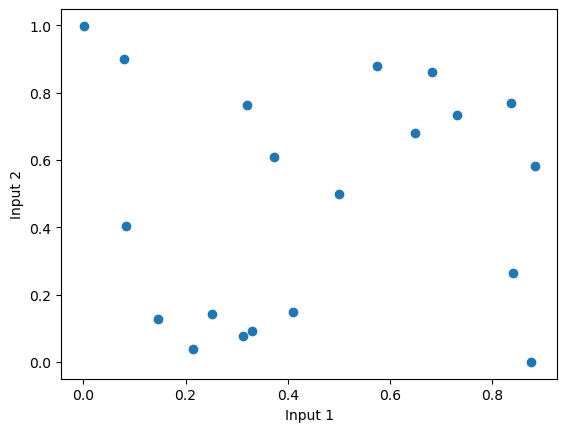

In [4]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2']])
Y = np.array(data[['Outputs']])
#Visualise explored points
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

In [5]:
#Using latin hypercube sampling to initialise a set of candidate points in a trust region
#Initialise points in the unit hypercube
d = 2
n = 10000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n) 

#Scale points generated in the unit hypercube to be inside trust region
#Trust hypercube of radius delta centered at best point with from observed data is 
#[x_best-delta, x_best_plus]
x_best = X[np.argmax(Y)]
#Set radius of hypercube
delta = 0.1
#lower and upper bounds of hypercube
lb = x_best-delta 
ub = x_best+delta

#scale points from unit hypercube to be inside trust region
scaled_grid = lb + grid * (ub-lb) 


In [6]:
#We now set the Kernel to be the Matern Kernel
nu = 1.5
kernel = Matern(
    length_scale_bounds=(1e-2, 2),
    nu= nu
)
print("Kernel:", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
print(gp)
gp.fit(X,Y)

mu, std = gp.predict(scaled_grid, return_std = True)

Kernel: Matern(length_scale=1, nu=1.5)
GaussianProcessRegressor(kernel=Matern(length_scale=1, nu=1.5),
                         normalize_y=True)


In [7]:
#Calculate UCB
beta = 0.2 #set exploration parameter
UCB = mu + beta*std
#Find point that maximises UCB
x_next = scaled_grid[np.argmax(UCB)]
print("Next suggested point:", np.round(x_next,6))


Next suggested point: [0.476915 0.506941]


In [3]:
#Week 12
#Add new data 
new_data = np.array([0.476915, 0.506941, 3.541143107520118e-8])
data.loc[len(data)] = new_data
data

,Input 1,Input 2,Outputs
0,0.319404,0.762959,1.320000e-79
1,0.574329,0.879898,1.030000e-46
2,0.731024,0.733000,7.710000e-16
3,0.840353,0.264732,3.340000e-124
4,0.650114,0.681526,-3.610000e-03
5,0.410437,0.147554,-2.160000e-54
6,0.312691,0.078723,-2.090000e-91
7,0.683418,0.861057,2.540000e-40
8,0.082507,0.403488,3.610000e-81
9,0.883890,0.582254,6.230000e-48


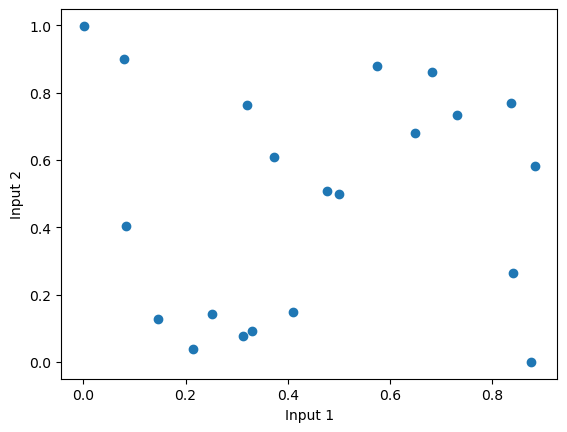

In [12]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2']])
Y = np.array(data[['Outputs']])
#Visualise explored points
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

In [20]:
#Using latin hypercube sampling to initialise a set of candidate points in a trust region
#Initialise points in the unit hypercube
d = 2
n = 10000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n) 

#Scale points generated in the unit hypercube to be inside trust region
#Trust hypercube of radius delta centered at best point with from observed data is 
#[x_best-delta, x_best_plus]
x_best = X[np.argmax(Y)]
#Set radius of hypercube to 10% higher than previous iteration 
delta = 0.1*1.1
#lower and upper bounds of hypercube
lb = x_best-delta 
ub = x_best+delta

#scale points from unit hypercube to be inside trust region
scaled_grid = lb + grid * (ub-lb) 
print("Center of hypercube:", x_best)
print("Upper bound", ub)
print("lower bound", lb)

In [14]:
#We now set the Kernel to be the Matern Kernel
nu = 1.5
kernel = Matern(
    length_scale_bounds=(1e-2, 2),
    nu= nu
)
print("Kernel:", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
print(gp)
gp.fit(X,Y)

mu, std = gp.predict(scaled_grid, return_std = True)

Kernel: Matern(length_scale=1, nu=1.5)
GaussianProcessRegressor(kernel=Matern(length_scale=1, nu=1.5),
                         normalize_y=True)


In [15]:
#Calculate UCB
beta = 0.2 #set exploration parameter
UCB = mu + beta*std
#Find point that maximises UCB
x_next = scaled_grid[np.argmax(UCB)]
print("Next suggested point:", np.round(x_next,6))

Next suggested point: [0.481518 0.474948]


In [4]:
#Week 13
#Add new data 
new_data = np.array([0.481518, 0.474948, 0.000012749562660281019])
data.loc[len(data)] = new_data
data

,Input 1,Input 2,Outputs
0,0.319404,0.762959,1.320000e-79
1,0.574329,0.879898,1.030000e-46
2,0.731024,0.733000,7.710000e-16
3,0.840353,0.264732,3.340000e-124
4,0.650114,0.681526,-3.610000e-03
5,0.410437,0.147554,-2.160000e-54
6,0.312691,0.078723,-2.090000e-91
7,0.683418,0.861057,2.540000e-40
8,0.082507,0.403488,3.610000e-81
9,0.883890,0.582254,6.230000e-48


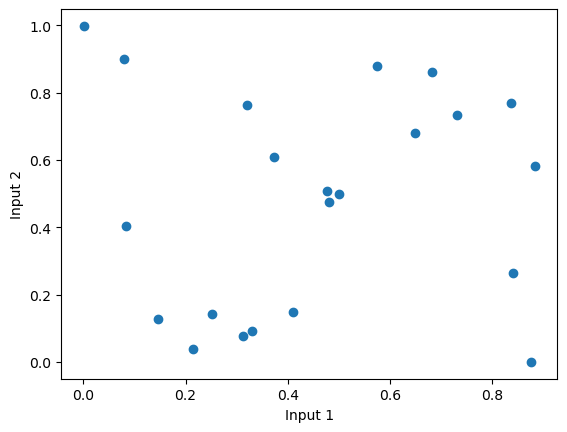

In [5]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2']])
Y = np.array(data[['Outputs']])
#Visualise explored points
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

In [7]:
#Using latin hypercube sampling to initialise a set of candidate points in a trust region
#Initialise points in the unit hypercube
d = 2
n = 10000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n) 

#Scale points generated in the unit hypercube to be inside trust region
#Trust hypercube of radius delta centered at best point with from observed data is 
#[x_best-delta, x_best_plus]
x_best = X[np.argmax(Y)]
#Set radius of hypercube to 10% higher than previous iteration 
delta = 0.1*1.1*1.1
#lower and upper bounds of hypercube
lb = x_best-delta 
ub = x_best+delta

#scale points from unit hypercube to be inside trust region
scaled_grid = lb + grid * (ub-lb) 
print("Center of hypercube:", x_best)
print("Upper bound", ub)
print("lower bound", lb)

Center of hypercube: [0.481518 0.474948]
Upper bound [0.602518 0.595948]
lower bound [0.360518 0.353948]


In [8]:
#We now set the Kernel to be the Matern Kernel
nu = 1.5
kernel = Matern(
    length_scale_bounds=(1e-2, 2),
    nu= nu
)
print("Kernel:", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
print(gp)
gp.fit(X,Y)

mu, std = gp.predict(scaled_grid, return_std = True)

Kernel: Matern(length_scale=1, nu=1.5)
GaussianProcessRegressor(kernel=Matern(length_scale=1, nu=1.5),
                         normalize_y=True)


In [14]:
#Calculate UCB
beta = 0.1 #set exploration parameter
UCB = mu + beta*std
#Find point that maximises UCB
x_next = scaled_grid[np.argmax(UCB)]
print("Next suggested point:", np.round(x_next,6))

Next suggested point: [0.485871 0.489074]
